In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                             classification_report)
from sklearn.utils.class_weight import compute_class_weight
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

In [2]:
core_path    = os.getcwd()
orbital_df = pd.read_pickle(os.path.join(core_path, 'data/lvl3/orbital_df.pkl'))

# Option A — family members only
family_df = orbital_df[orbital_df['is_family_member']].copy().reset_index(drop=True)

print(f"Family members   : {len(family_df):,}")
print(f"Unique families  : {family_df['family_1'].nunique()}")
print(f"\nFamily size stats:")
print(family_df.groupby('family_1').size().describe())

Family members   : 230,607
Unique families  : 98

Family size stats:
count       98.000000
mean      2353.132653
std       5239.487654
min          3.000000
25%        114.750000
50%        407.500000
75%       1900.250000
max      34323.000000
dtype: float64


In [3]:
FEATURES_A = ['a_p', 'e_p', 'sin_i_p', 'g', 's']
FEATURES_B = ['a_p', 'e_p', 'sin_i_p', 'g', 's',
              'rms_a', 'rms_e', 'rms_sin_i', 'LCE']

# Encode family labels 0..97
le = LabelEncoder()
y  = le.fit_transform(family_df['family_1'].values)

print(f"Classes          : {len(le.classes_)}")
print(f"Label range      : {y.min()} – {y.max()}")

# Class weights for imbalanced families
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(le.classes_)),
    y=y
)
class_weight_dict = dict(enumerate(class_weights_arr))
print(f"\nMin class weight : {class_weights_arr.min():.3f}")
print(f"Max class weight : {class_weights_arr.max():.3f}")

Classes          : 98
Label range      : 0 – 97

Min class weight : 0.069
Max class weight : 784.378


In [4]:
rf_results = {}

for feat_name, features in [
    ('Set_A_orbital', FEATURES_A),
    ('Set_B_full',    FEATURES_B),
]:
    print(f"\n{'='*55}")
    print(f"Feature {feat_name}")
    print(f"{'='*55}")

    X = family_df[features].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    scaler  = RobustScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    print(f"Train : {len(X_train):,} | Test : {len(X_test):,}")

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    print("Training Random Forest...")
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)

    acc       = accuracy_score(y_test, y_pred)
    f1_macro  = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')

    print(f"\n=== RF Multiclass — {feat_name} ===")
    print(f"Accuracy        : {acc:.4f}")
    print(f"F1 Macro        : {f1_macro:.4f}")
    print(f"F1 Weighted     : {f1_weighted:.4f}")

    # Per-class F1
    per_class_f1 = f1_score(y_test, y_pred, average=None)
    print(f"\nPer-class F1:")
    print(f"  Min  : {per_class_f1.min():.4f}  (family {le.classes_[per_class_f1.argmin()]})")
    print(f"  Max  : {per_class_f1.max():.4f}  (family {le.classes_[per_class_f1.argmax()]})")
    print(f"  Mean : {per_class_f1.mean():.4f}")

    rf_results[feat_name] = {
        'model': rf, 'scaler': scaler,
        'y_test': y_test, 'y_pred': y_pred,
        'acc': acc, 'f1_macro': f1_macro, 'f1_weighted': f1_weighted,
        'per_class_f1': per_class_f1, 'features': features,
        'importances': rf.feature_importances_
    }


Feature Set_A_orbital
Train : 184,485 | Test : 46,122
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.7min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    1.5s
[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    2.5s finished



=== RF Multiclass — Set_A_orbital ===
Accuracy        : 0.9992
F1 Macro        : 0.9919
F1 Weighted     : 0.9992

Per-class F1:
  Min  : 0.8571  (family 10369)
  Max  : 1.0000  (family 2)
  Mean : 0.9919

Feature Set_B_full
Train : 184,485 | Test : 46,122
Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:   10.3s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   55.3s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:  1.5min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.2s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    1.3s



=== RF Multiclass — Set_B_full ===
Accuracy        : 0.9992
F1 Macro        : 0.9941
F1 Weighted     : 0.9992

Per-class F1:
  Min  : 0.9048  (family 21885)
  Max  : 1.0000  (family 2)
  Mean : 0.9941


[Parallel(n_jobs=12)]: Done 300 out of 300 | elapsed:    2.2s finished


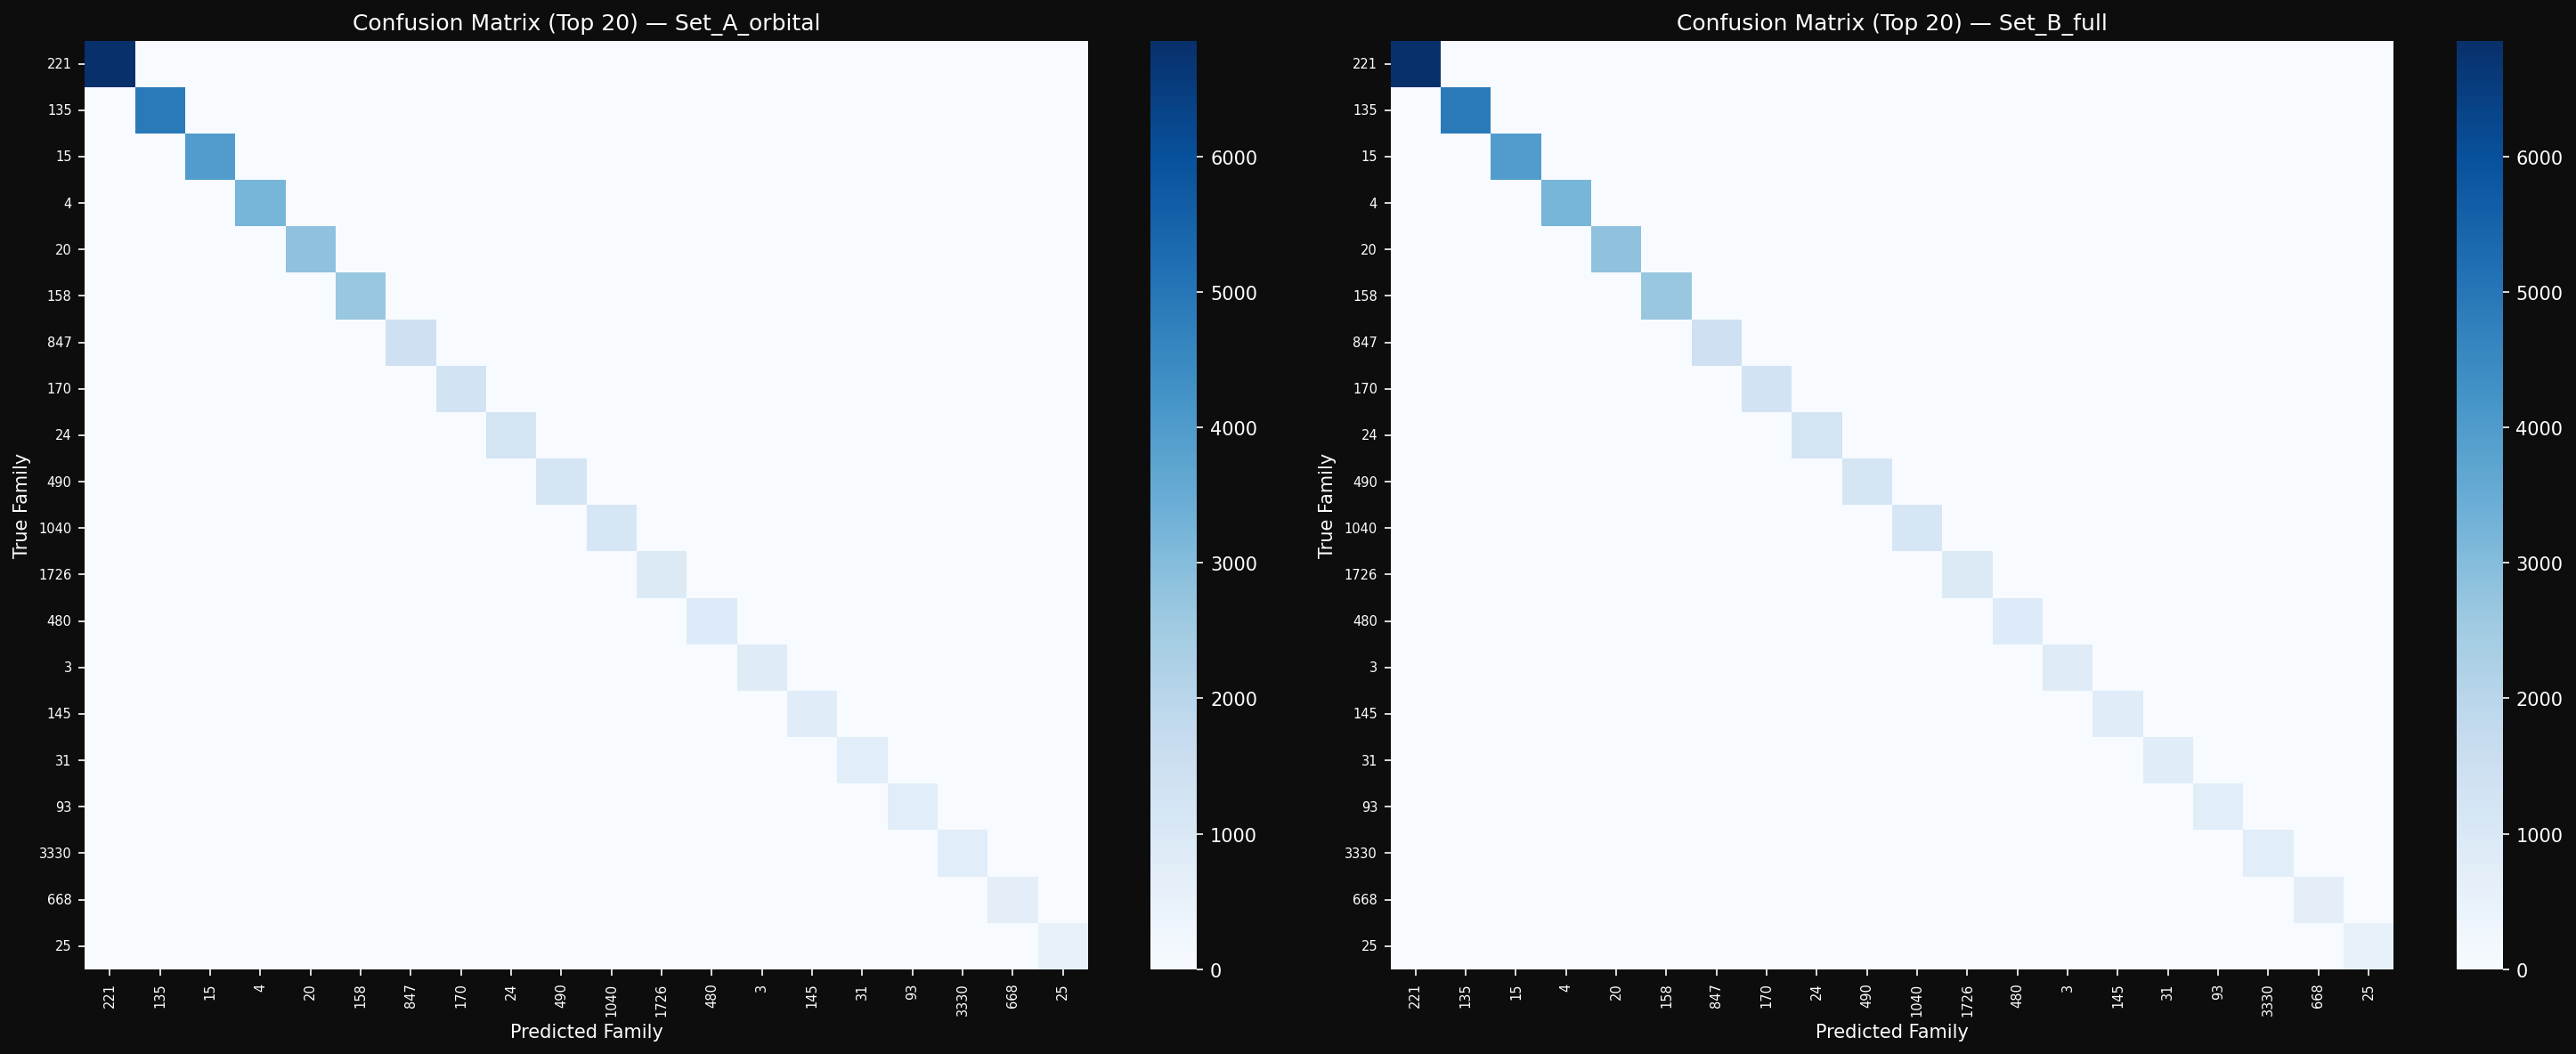

In [5]:
top20_families = (
    family_df.groupby('family_1').size()
    .sort_values(ascending=False)
    .head(20).index.tolist()
)
top20_encoded = le.transform(top20_families)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, feat_name in zip(axes, ['Set_A_orbital', 'Set_B_full']):
    res = rf_results[feat_name]

    # Filter test set to top 20 families
    mask     = np.isin(res['y_test'], top20_encoded)
    y_t      = res['y_test'][mask]
    y_p      = res['y_pred'][mask]

    # Remap to 0..19 for display
    remap    = {v: i for i, v in enumerate(top20_encoded)}
    y_t_r    = np.array([remap[v] for v in y_t])
    y_p_r    = np.array([remap.get(v, -1) for v in y_p])

    cm = confusion_matrix(y_t_r, y_p_r,
                          labels=list(range(len(top20_families))))

    sns.heatmap(cm, annot=False, cmap='Blues',
                xticklabels=top20_families,
                yticklabels=top20_families,
                ax=ax)
    ax.set_xlabel('Predicted Family')
    ax.set_ylabel('True Family')
    ax.set_title(f'Confusion Matrix (Top 20) — {feat_name}')
    plt.setp(ax.get_xticklabels(), rotation=90, fontsize=7)
    plt.setp(ax.get_yticklabels(), rotation=0,  fontsize=7)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05b_i_rf_confusion_top20.png'), dpi=200, bbox_inches='tight')
plt.show()

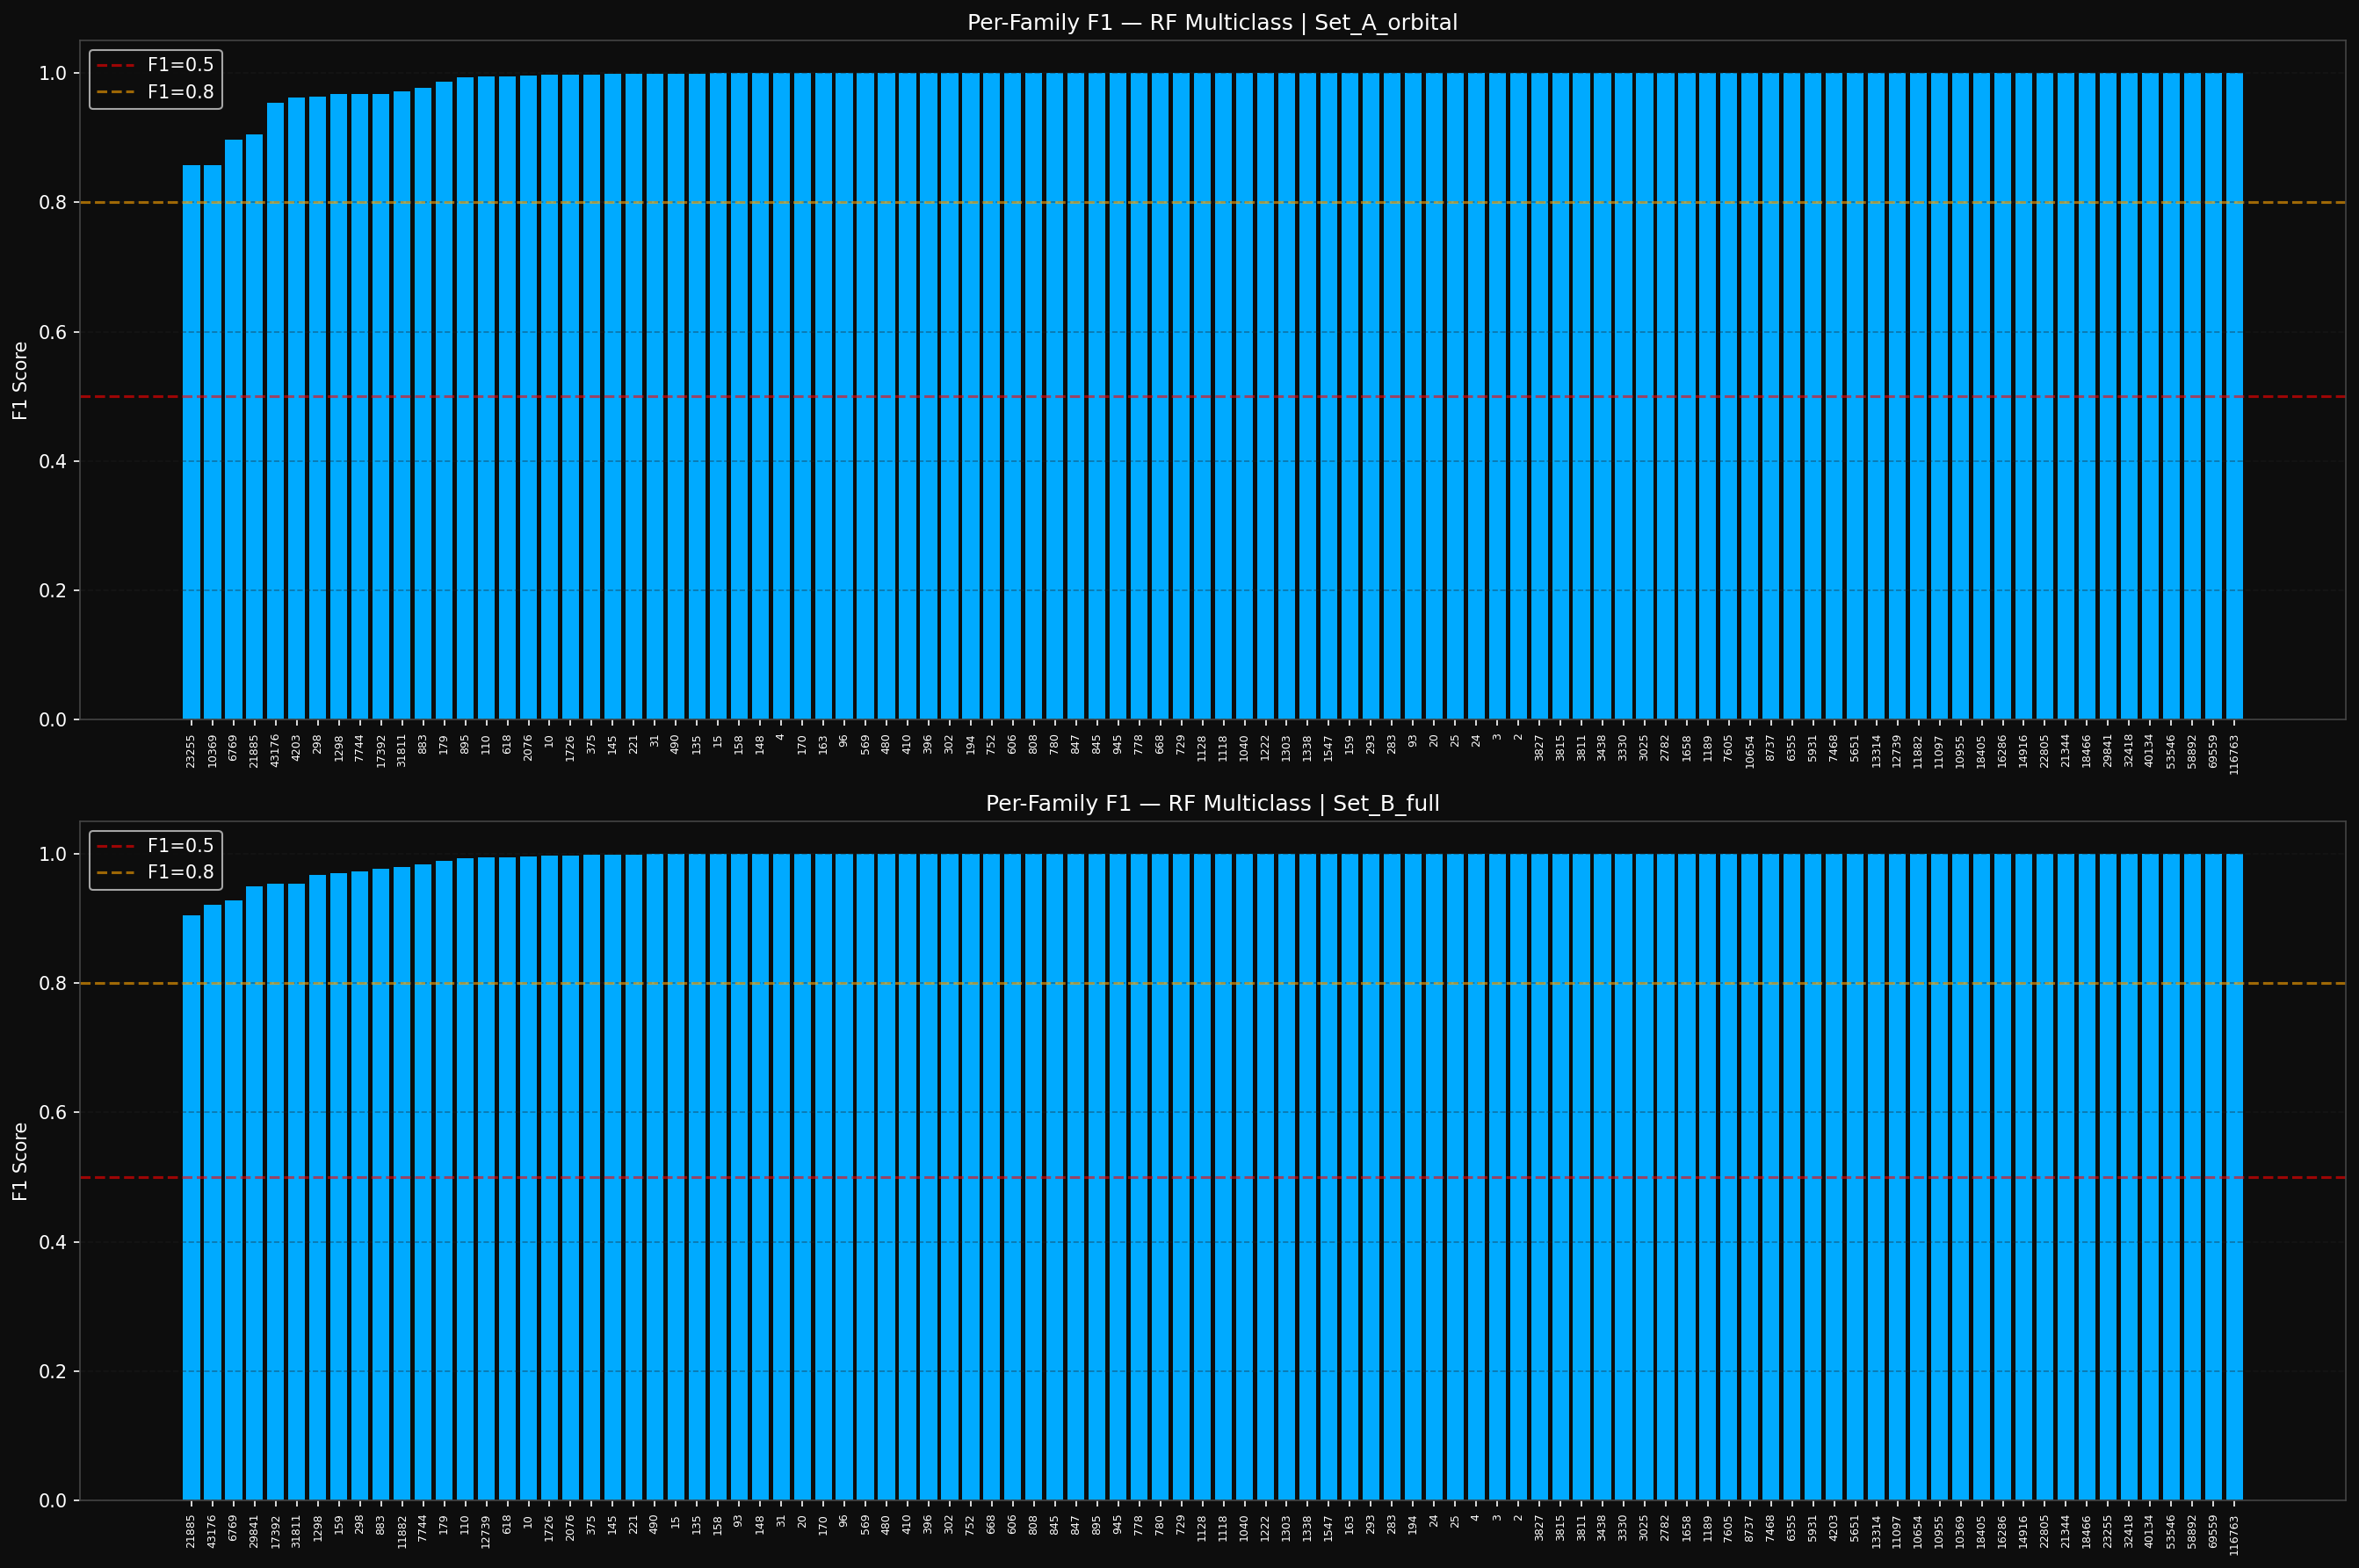

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

for ax, feat_name in zip(axes, ['Set_A_orbital', 'Set_B_full']):
    res          = rf_results[feat_name]
    per_f1       = res['per_class_f1']
    sorted_idx   = np.argsort(per_f1)
    family_names = [str(le.classes_[i]) for i in sorted_idx]

    colors = ['#ff4444' if f < 0.5 else '#ffaa00' if f < 0.8 else '#00aaff'
              for f in per_f1[sorted_idx]]

    ax.bar(range(len(per_f1)), per_f1[sorted_idx], color=colors, edgecolor='none')
    ax.axhline(0.5, color='red',    linestyle='--', alpha=0.6, label='F1=0.5')
    ax.axhline(0.8, color='orange', linestyle='--', alpha=0.6, label='F1=0.8')
    ax.set_xticks(range(len(per_f1)))
    ax.set_xticklabels(family_names, rotation=90, fontsize=6)
    ax.set_ylabel('F1 Score')
    ax.set_title(f'Per-Family F1 — RF Multiclass | {feat_name}')
    ax.legend()
    ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05b_i_rf_perclass_f1.png'), dpi=200, bbox_inches='tight')
plt.show()

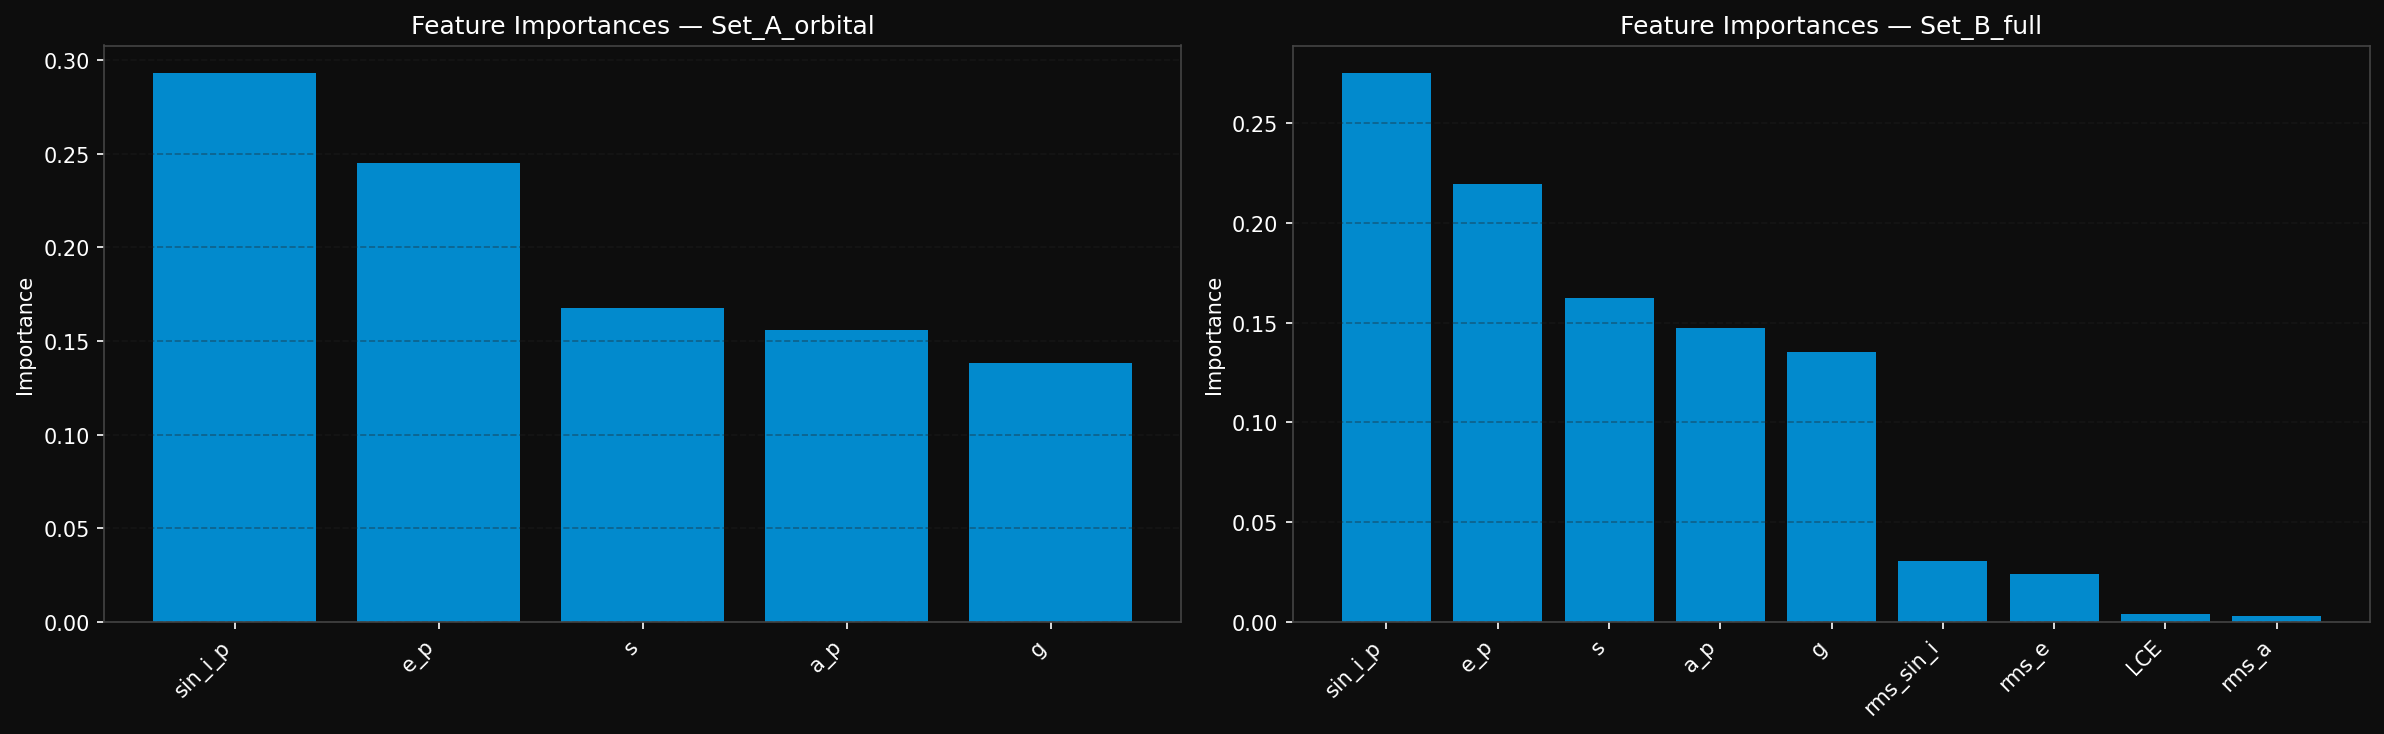

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, feat_name in zip(axes, ['Set_A_orbital', 'Set_B_full']):
    res         = rf_results[feat_name]
    importances = res['importances']
    features    = res['features']
    sorted_idx  = np.argsort(importances)[::-1]

    ax.bar(range(len(features)),
           importances[sorted_idx],
           color='#00aaff', edgecolor='none', alpha=0.8)
    ax.set_xticks(range(len(features)))
    ax.set_xticklabels([features[i] for i in sorted_idx], rotation=45, ha='right')
    ax.set_ylabel('Importance')
    ax.set_title(f'Feature Importances — {feat_name}')
    ax.grid(True, axis='y')

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '05b_i_rf_importances.png'), dpi=200, bbox_inches='tight')
plt.show()

In [8]:
print(f"\n{'='*65}")
print(f"{'RF Multiclass — Summary':^65}")
print(f"{'='*65}")
print(f"{'Feature Set':<20} {'Acc':>8} {'F1 Macro':>10} {'F1 Weighted':>12}")
print(f"{'-'*65}")
for feat_name, res in rf_results.items():
    print(f"{feat_name:<20} {res['acc']:>8.4f} {res['f1_macro']:>10.4f} {res['f1_weighted']:>12.4f}")


                     RF Multiclass — Summary                     
Feature Set               Acc   F1 Macro  F1 Weighted
-----------------------------------------------------------------
Set_A_orbital          0.9992     0.9919       0.9992
Set_B_full             0.9992     0.9941       0.9992


In [9]:
for feat_name, res in rf_results.items():
    per_f1     = res['per_class_f1']
    min_idx    = per_f1.argmin()
    min_family = le.classes_[min_idx]
    min_size   = family_df[family_df['family_1'] == min_family].shape[0]
    print(f"{feat_name}: min F1={per_f1.min():.4f} → family {min_family} ({min_size} members)")

Set_A_orbital: min F1=0.8571 → family 10369 (34 members)
Set_B_full: min F1=0.9048 → family 21885 (104 members)


In [11]:
save_dict = {
    feat_name: {k: v for k, v in res.items() if k != 'model'}
    for feat_name, res in rf_results.items()
}

with open(os.path.join('data', 'results', 'classification_results', '07a_i_multiclass_rf_results.pkl'), 'wb') as f:
    pickle.dump(save_dict, f)

print("Saved → data/results/07a_i_multiclass_rf_results.pkl")

Saved → data/results/07a_i_multiclass_rf_results.pkl
